<a href="https://colab.research.google.com/github/MoeTahech/real-fake-face-detection-thesis/blob/main/08_frequency_domain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08 — Phase 8: Frequency-Domain Detection

Tests whether representing each face image in the **frequency domain**
(via 2D FFT) rather than raw RGB pixels leads to better generalization across
forgery types. GAN and diffusion generators tend to leave subtle, repeating
artifacts that are more visible as distinct patterns in the frequency
spectrum than in raw pixels — the hypothesis here is that these patterns may
be a more universal "this is machine-generated" signal than raw pixel
artifacts, which Phase 2 showed generalize poorly (SOTA review, Section 4.2).

**Design:** trained single-source (StyleGAN only, matching Phase 2's setup
exactly, but on frequency-domain input instead of RGB), then evaluated on the
same three test sets already used elsewhere in this project — StyleGAN
(in-distribution), face-swap (Phase 3's cross-dataset test), and diffusion
(Phase 7's third-domain test) — for direct, apples-to-apples comparison
against Phase 2's RGB-based results.

Runtime → Change runtime type → GPU, then run cells top to bottom.

### Step 1 — Confirm you have a GPU

In [ ]:
!nvidia-smi

### Step 2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/thesis_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("Checkpoints will be saved to / loaded from:", CHECKPOINT_DIR)

Mounted at /content/drive
Checkpoints will be saved to / loaded from: /content/drive/MyDrive/thesis_checkpoints


### Step 3 — Kaggle API access (via Colab Secrets)

Requires secrets `KAGGLE_USERNAME` and `KAGGLE_KEY` already set up (🔑 icon,
left sidebar).

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_305e81603250999b12324cc02e529f89"

### Step 4 — Download all three datasets (needed for the three-way evaluation later)

In [ ]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d data_raw

!kaggle datasets download -d manjilkarki/deepfake-and-real-images
!unzip -q deepfake-and-real-images.zip -d data_raw_2

!kaggle datasets download -d bwandowando/faces-dataset-using-stable-diffusion-v14
!unzip -q faces-dataset-using-stable-diffusion-v14.zip -d data_diffusion
print("All three datasets downloaded.")

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [01:47<00:00, 37.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images
License(s): unknown
100% 1.68G/1.68G [00:55<00:00, 32.7MB/s]

Dataset URL: https://www.kaggle.com/datasets/bwandowando/faces-dataset-using-stable-diffusion-v14
License(s): CC0-1.0
100% 1.10G/1.10G [00:36<00:00, 32.3MB/s]

All three datasets downloaded.


### Step 5 — Locate folders in all three datasets

Same robust auto-detection approach used throughout this project.

In [ ]:
import os

def find_real_fake_folders(root):
    candidates = []
    for dirpath, dirnames, _ in os.walk(root):
        lower = [d.lower() for d in dirnames]
        if "real" in lower and "fake" in lower:
            candidates.append(dirpath)
    return candidates

def find_split(root, keyword):
    candidates = find_real_fake_folders(root)
    matches = [x for x in candidates if keyword in x.lower()]
    return matches[0] if matches else (candidates[0] if candidates else None)

def find_class_dir(split_root, class_name):
    for d in os.listdir(split_root):
        if d.lower() == class_name:
            return os.path.join(split_root, d)
    raise FileNotFoundError(f"No '{class_name}' folder in {split_root}")

def find_all_images(root, exts=(".jpg", ".jpeg", ".png")):
    found = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower().endswith(exts):
                found.append(os.path.join(dirpath, fname))
    return found

styleGAN_train = find_split("data_raw", "train")
styleGAN_val = find_split("data_raw", "val") or find_split("data_raw", "valid")
styleGAN_test = find_split("data_raw", "test")
faceswap_test = find_split("data_raw_2", "test")
diffusion_images = find_all_images("data_diffusion")

print("StyleGAN train:", styleGAN_train)
print("StyleGAN val:  ", styleGAN_val)
print("StyleGAN test: ", styleGAN_test)
print("Face-swap test:", faceswap_test)
print("Diffusion images found:", len(diffusion_images))

StyleGAN train: data_raw/real_vs_fake/real-vs-fake/train
StyleGAN val:   data_raw/real_vs_fake/real-vs-fake/valid
StyleGAN test:  data_raw/real_vs_fake/real-vs-fake/test
Face-swap test: data_raw_2/Dataset/Test
Diffusion images found: 2536


### Step 6 — Define the frequency-domain transform

Converts an image tensor to its 2D FFT log-magnitude spectrum, one channel
at a time. `fftshift` centers the low frequencies in the middle of the image
(the conventional way to visualize/process a frequency spectrum). The result
is standardized (zero mean, unit variance) per image, since frequency
magnitudes have a very different numeric scale than normal pixel values and
should not use standard ImageNet pixel normalization.

In [ ]:
import torch

def to_frequency_domain(img_tensor):
    """img_tensor: (C, H, W) in [0, 1]. Returns log-magnitude FFT spectrum, same shape."""
    freq_channels = []
    for ch in range(img_tensor.shape[0]):
        f = torch.fft.fft2(img_tensor[ch])
        f = torch.fft.fftshift(f)
        magnitude = torch.log(torch.abs(f) + 1e-8)
        freq_channels.append(magnitude)
    freq = torch.stack(freq_channels, dim=0)
    freq = (freq - freq.mean()) / (freq.std() + 1e-8)
    return freq

print("Frequency-domain transform ready.")

Frequency-domain transform ready.


### Step 7 — Visualize a couple of examples (sanity check)

Confirms the transform produces sensible, visibly different spectra —
worth a quick look before training on it blindly.

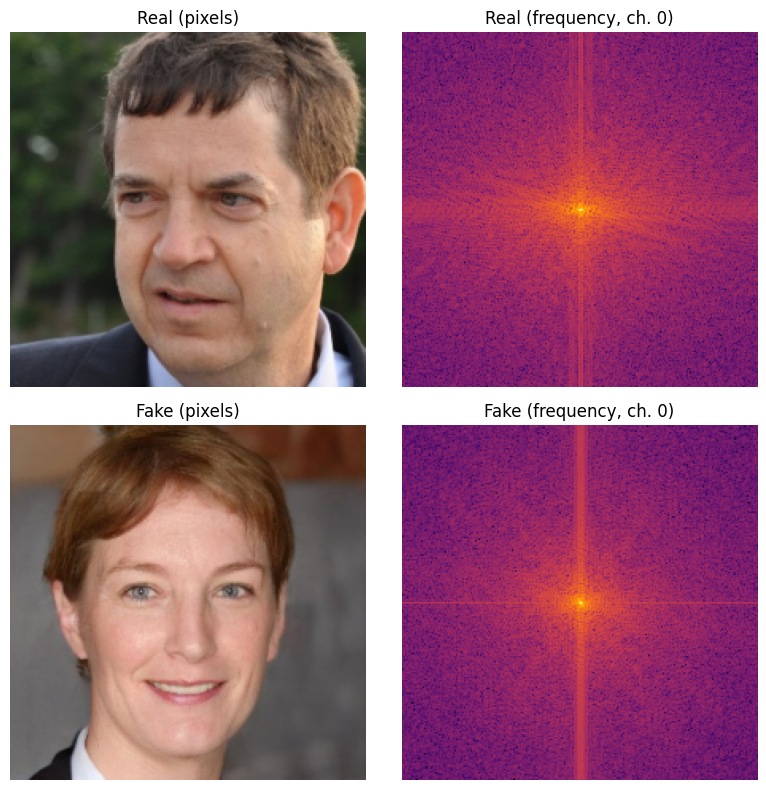

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

to_tensor = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])

real_dir = find_class_dir(styleGAN_test, "real")
fake_dir = find_class_dir(styleGAN_test, "fake")
real_img = to_tensor(Image.open(os.path.join(real_dir, os.listdir(real_dir)[0])).convert("RGB"))
fake_img = to_tensor(Image.open(os.path.join(fake_dir, os.listdir(fake_dir)[0])).convert("RGB"))

real_freq = to_frequency_domain(real_img)
fake_freq = to_frequency_domain(fake_img)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0,0].imshow(real_img.permute(1,2,0)); axes[0,0].set_title("Real (pixels)"); axes[0,0].axis("off")
axes[0,1].imshow(real_freq[0], cmap="inferno"); axes[0,1].set_title("Real (frequency, ch. 0)"); axes[0,1].axis("off")
axes[1,0].imshow(fake_img.permute(1,2,0)); axes[1,0].set_title("Fake (pixels)"); axes[1,0].axis("off")
axes[1,1].imshow(fake_freq[0], cmap="inferno"); axes[1,1].set_title("Fake (frequency, ch. 0)"); axes[1,1].axis("off")
plt.tight_layout()
plt.show()

### Step 8 — Build the frequency-domain data loaders

Uses the standard `ImageFolder` + `transforms.Compose` pattern, with the FFT
transform appended after converting to a tensor.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

freq_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(to_frequency_domain),
])

train_set = datasets.ImageFolder(styleGAN_train, transform=freq_transform)
val_set = datasets.ImageFolder(styleGAN_val, transform=freq_transform)
print("Class mapping:", train_set.class_to_idx)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2)
print("Train size:", len(train_set), " Val size:", len(val_set))

Class mapping: {'fake': 0, 'real': 1}
Train size: 100000  Val size: 20000


### Step 9 — Build and train the frequency-domain model

Because the input domain (frequency spectra) is very different from the
natural images ResNet18 was pretrained on, **the entire network is unfrozen**
here (full fine-tuning), not just the last block as in Phase 2 — the
low-level pretrained filters (edge detectors tuned for natural images) are
not expected to be as useful a starting point for this input type. The
pretrained weights are still used as an initialization, which is common
practice even under domain shift, but every layer is allowed to adapt.

In [ ]:
%%writefile train_frequency.py
"""
Train ResNet18 (fully unfrozen) on frequency-domain (FFT) representations
of face images, on the StyleGAN dataset only (single-source, matches Phase 2).

Usage:
    python train_frequency.py --epochs 5 --batch_size 64 --lr 1e-4 --checkpoint_dir .
"""
import argparse
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm


def to_frequency_domain(img_tensor):
    freq_channels = []
    for ch in range(img_tensor.shape[0]):
        f = torch.fft.fft2(img_tensor[ch])
        f = torch.fft.fftshift(f)
        magnitude = torch.log(torch.abs(f) + 1e-8)
        freq_channels.append(magnitude)
    freq = torch.stack(freq_channels, dim=0)
    freq = (freq - freq.mean()) / (freq.std() + 1e-8)
    return freq


def get_dataloaders(train_dir, val_dir, batch_size, img_size=224):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Lambda(to_frequency_domain),
    ])
    train_set = datasets.ImageFolder(train_dir, transform=transform)
    val_set = datasets.ImageFolder(val_dir, transform=transform)
    print("Class mapping:", train_set.class_to_idx)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader, train_set.class_to_idx


def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Fully unfrozen: input domain (frequency spectra) differs substantially
    # from natural images, so pretrained low-level filters are used only as
    # an initialization, not frozen as fixed generic features.
    for param in model.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, desc="train" if train else "val"):
            images, labels = images.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--train_dir", type=str, required=True)
    parser.add_argument("--val_dir", type=str, required=True)
    parser.add_argument("--epochs", type=int, default=5)
    parser.add_argument("--batch_size", type=int, default=64)
    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--checkpoint_dir", type=str, default=".")
    args = parser.parse_args()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    train_loader, val_loader, class_to_idx = get_dataloaders(args.train_dir, args.val_dir, args.batch_size)
    model = build_model().to(device)
    criterion = nn.CrossEntropyLoss()

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in trainable_params)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {n_trainable:,} / {n_total:,}")

    optimizer = torch.optim.Adam(trainable_params, lr=args.lr)

    os.makedirs(args.checkpoint_dir, exist_ok=True)
    save_path = os.path.join(args.checkpoint_dir, "best_model_frequency.pth")

    best_val_acc = 0.0
    for epoch in range(args.epochs):
        print(f"\nEpoch {epoch + 1}/{args.epochs}")
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, device, train=False)
        print(f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({"model_state": model.state_dict(), "class_to_idx": class_to_idx}, save_path)
            print(f"Saved new best model to {save_path} (val_acc={val_acc:.4f})")

    print(f"\nDone. Best validation accuracy: {best_val_acc:.4f}")
    print(f"Final checkpoint is at: {save_path}")


if __name__ == "__main__":
    main()


Writing train_frequency.py


### Step 10 — Train (this may take longer than Phase 2, since the full network is now trainable)

In [ ]:
!python train_frequency.py --train_dir "{styleGAN_train}" --val_dir "{styleGAN_val}" --epochs 5 --batch_size 64 --lr 1e-4 --checkpoint_dir "{CHECKPOINT_DIR}"

Using device: cuda
Class mapping: {'fake': 0, 'real': 1}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 174MB/s]
Trainable parameters: 11,177,538 / 11,177,538

Epoch 1/5
train: 100% 1563/1563 [12:19<00:00,  2.11it/s]
val: 100% 313/313 [02:11<00:00,  2.37it/s]
train_loss=0.4988 train_acc=0.7513 val_loss=0.4507 val_acc=0.7905
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model_frequency.pth (val_acc=0.7905)

Epoch 2/5
train: 100% 1563/1563 [12:06<00:00,  2.15it/s]
val: 100% 313/313 [02:11<00:00,  2.39it/s]
train_loss=0.3599 train_acc=0.8400 val_loss=0.3852 val_acc=0.8236
Saved new best model to /content/drive/MyDrive/thesis_checkpoints/best_model_frequency.pth (val_acc=0.8236)

Epoch 3/5
train: 100% 1563/1563 [11:42<00:00,  2.22it/s]
val: 100% 313/313 [02:02<00:00,  2.56it/s]
train_loss=0.2686 train_acc=0.8865 val_loss=0.3820 val_acc=0.8333
Saved n

### Step 11 — Build the three evaluation sets (frequency-domain versions)

Same three domains used throughout this project — StyleGAN (in-distribution),
face-swap (Phase 3), and diffusion (Phase 7) — capped at manageable sizes,
now transformed into frequency-domain representations for evaluation.

In [ ]:
import random

def build_eval_subset_imagefolder(source_root, dst_root, n_per_class, seed=99):
    rng = random.Random(seed)
    for cls in ["real", "fake"]:
        dst = os.path.join(dst_root, cls)
        os.makedirs(dst, exist_ok=True)
        cls_dir = find_class_dir(source_root, cls)
        files = os.listdir(cls_dir)
        rng.shuffle(files)
        for fname in files[:n_per_class]:
            src = os.path.abspath(os.path.join(cls_dir, fname))
            dst_path = os.path.join(dst, fname)
            if not os.path.exists(dst_path):
                os.symlink(src, dst_path)

build_eval_subset_imagefolder(styleGAN_test, "eval_styleGAN_freq", n_per_class=5000)
build_eval_subset_imagefolder(faceswap_test, "eval_faceswap_freq", n_per_class=5000)

# Diffusion: fakes-only dataset, paired with held-out StyleGAN real images (same approach as Phase 7)
real_dir = find_class_dir(styleGAN_test, "real")
real_images = [os.path.join(real_dir, f) for f in os.listdir(real_dir)]

def build_eval_diffusion(dst_root, fake_paths, real_paths, n_per_class, seed=7):
    rng = random.Random(seed)
    fake_dst = os.path.join(dst_root, "fake")
    real_dst = os.path.join(dst_root, "real")
    os.makedirs(fake_dst, exist_ok=True)
    os.makedirs(real_dst, exist_ok=True)
    fake_sample = fake_paths[:]; rng.shuffle(fake_sample); fake_sample = fake_sample[:n_per_class]
    real_sample = real_paths[:]; rng.shuffle(real_sample); real_sample = real_sample[:n_per_class]
    for i, path in enumerate(fake_sample):
        dst = os.path.join(fake_dst, f"{i}_{os.path.basename(path)}")
        if not os.path.exists(dst):
            os.symlink(os.path.abspath(path), dst)
    for i, path in enumerate(real_sample):
        dst = os.path.join(real_dst, f"{i}_{os.path.basename(path)}")
        if not os.path.exists(dst):
            os.symlink(os.path.abspath(path), dst)

build_eval_diffusion("eval_diffusion_freq", diffusion_images, real_images, n_per_class=5000)
print("All three frequency-domain evaluation sets built.")

All three frequency-domain evaluation sets built.


### Step 12 — Evaluate the frequency-domain model on all three domains

Compare these numbers directly against Phase 2's RGB-based results:
StyleGAN 98.8% acc / 0.999 AUC, Face-swap 49.8% acc / 0.525 AUC,
Diffusion 65.5% acc / 0.277 AUC.

In [ ]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

freq_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(to_frequency_domain),
])

checkpoint = torch.load(f"{CHECKPOINT_DIR}/best_model_frequency.pth", map_location=device)
class_to_idx = checkpoint["class_to_idx"]
real_idx = class_to_idx["real"]
print("Class mapping:", class_to_idx)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(checkpoint["model_state"])
model.to(device).eval()


def evaluate(test_dir):
    test_set = datasets.ImageFolder(test_dir, transform=freq_eval_transform)
    loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)
    remap = {idx: class_to_idx[name.lower()] for name, idx in test_set.class_to_idx.items()}

    all_labels, all_probs, all_preds = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)[:, real_idx].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend([remap[l.item()] for l in labels])

    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, auc, cm


print(f"{'Test domain':<20} {'Accuracy':<12} {'AUC':<10}")
for name, test_dir in [("StyleGAN", "eval_styleGAN_freq"),
                         ("Face-swap", "eval_faceswap_freq"),
                         ("Diffusion", "eval_diffusion_freq")]:
    acc, auc, cm = evaluate(test_dir)
    print(f"{name:<20} {acc:<12.4f} {auc:<10.4f}")
    print(f"  Confusion matrix:\n{cm}\n")

print("\n--- Reference: Phase 2 (RGB, single-source) for comparison ---")
print("StyleGAN:  Accuracy=0.9868  AUC=0.999")
print("Face-swap: Accuracy=0.4978  AUC=0.525")
print("Diffusion: Accuracy=0.655   AUC=0.277")

Class mapping: {'fake': 0, 'real': 1}
Test domain          Accuracy     AUC       
StyleGAN             0.8378       0.9201    
  Confusion matrix:
[[4186  814]
 [ 808 4192]]

Face-swap            0.5013       0.5605    
  Confusion matrix:
[[ 342 4658]
 [ 329 4671]]

Diffusion            0.5760       0.3027    
  Confusion matrix:
[[ 157 2379]
 [ 816 4184]]


--- Reference: Phase 2 (RGB, single-source) for comparison ---
StyleGAN:  Accuracy=0.9868  AUC=0.999
Face-swap: Accuracy=0.4978  AUC=0.525
Diffusion: Accuracy=0.655   AUC=0.277


---
### What to save for this phase
- The visualized frequency spectra (Step 7) — good illustrative figure for
  your report
- Trainable parameter count and training curve (Step 10)
- The full three-domain accuracy/AUC table from Step 12, compared directly
  against the Phase 2 RGB reference numbers printed at the end

**How to interpret the result:**
- If the frequency-domain model's Face-swap and/or Diffusion AUC are
  meaningfully higher than Phase 2's RGB-based numbers (0.525 and 0.277),
  that supports the hypothesis that frequency-domain artifacts generalize
  better across generator types than raw pixel artifacts.
- If performance is similar or worse across the board, that is also a
  valid, reportable finding — it would suggest the generalization problem
  is not simply about input representation, and is consistent with the
  broader difficulty of this problem noted in the SOTA review.

Send me the full output and we'll add this as the next section of your report.